C:\Users\saura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


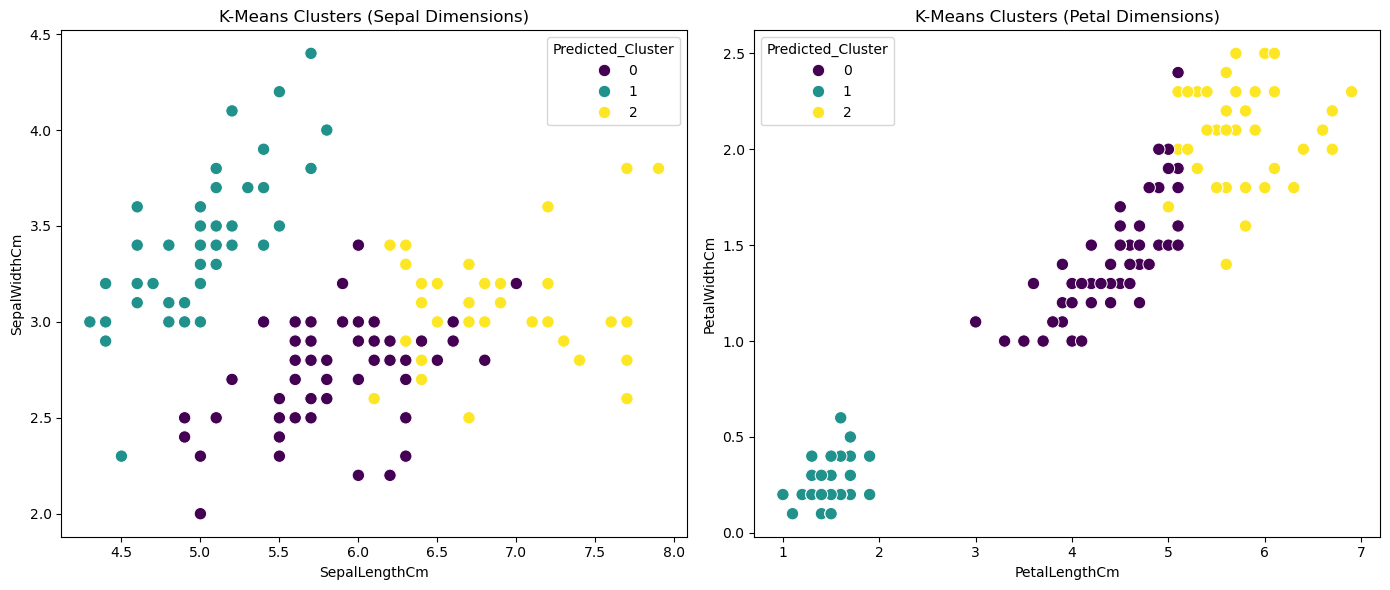

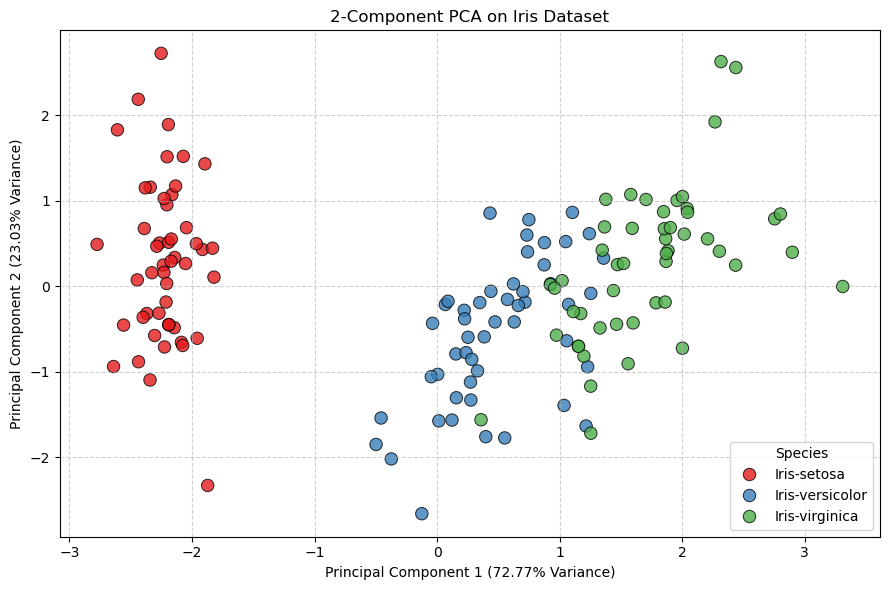

Comparison Table:

Predicted Cluster   0   1   2
True Species                 
Iris-setosa         0  50   0
Iris-versicolor    48   0   2
Iris-virginica     14   0  36


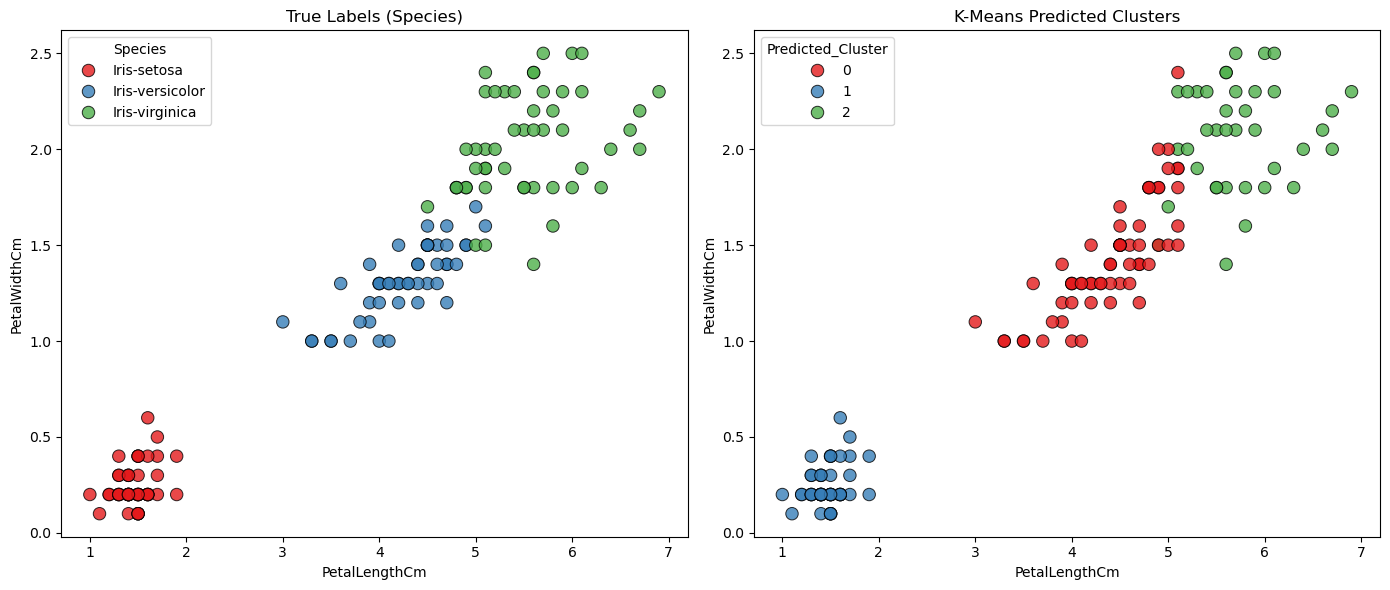

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Load the Dataset
# ==========================================
# Ensure 'Iris.csv' is in the same directory as this script
df = pd.read_csv('Iris.csv')

# Extract the four numerical features
feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X = df[feature_cols]

# ==========================================
# 2. K-Means Clustering
# ==========================================
# Initialize and fit K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Predicted_Cluster'] = kmeans.fit_predict(X)

# Visualize K-Means Clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Sepal Dimensions
sns.scatterplot(ax=axes[0], x='SepalLengthCm', y='SepalWidthCm', 
                hue='Predicted_Cluster', data=df, palette='viridis', s=80)
axes[0].set_title('K-Means Clusters (Sepal Dimensions)')

# Subplot 2: Petal Dimensions
sns.scatterplot(ax=axes[1], x='PetalLengthCm', y='PetalWidthCm', 
                hue='Predicted_Cluster', data=df, palette='viridis', s=80)
axes[1].set_title('K-Means Clusters (Petal Dimensions)')

plt.tight_layout()
plt.show()

# ==========================================
# 3. Principal Component Analysis (PCA)
# ==========================================
# Standardize features (mean=0, variance=1) - crucial for PCA
X_scaled = StandardScaler().fit_transform(X)

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Attach true 'Species' labels to the PCA results for visualization
final_pca_df = pd.concat([pca_df, df['Species']], axis=1)

# Visualize PCA
plt.figure(figsize=(9, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Species', data=final_pca_df, 
                palette='Set1', s=80, edgecolor='k', alpha=0.8)
plt.title('2-Component PCA on Iris Dataset')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# 4. Compare Predicted Clusters vs True Labels
# ==========================================
# Print a cross-tabulation matrix
comparison = pd.crosstab(df['Species'], df['Predicted_Cluster'], 
                         rownames=['True Species'], colnames=['Predicted Cluster'])
print("Comparison Table:\n")
print(comparison)

# Visualize True Labels vs Predicted Clusters side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# True Labels
sns.scatterplot(ax=axes[0], x='PetalLengthCm', y='PetalWidthCm', 
                hue='Species', data=df, palette='Set1', s=80, edgecolor='k', alpha=0.8)
axes[0].set_title('True Labels (Species)')

# Predicted Clusters
sns.scatterplot(ax=axes[1], x='PetalLengthCm', y='PetalWidthCm', 
                hue='Predicted_Cluster', data=df, palette='Set1', s=80, edgecolor='k', alpha=0.8, legend='full')
axes[1].set_title('K-Means Predicted Clusters')

plt.tight_layout()
plt.show()